### Exercise 1:
An autonomous delivery robot must navigate a grid-based warehouse to reach a goal location while avoiding obstacles.  

The environment is represented as a grid:  
* Each cell = a state  
* Actions = {Up, Down, Left, Right}  
* Some cells contain obstacles (cannot enter)  
* One cell is the goal state  

1. Formulate the problem as an RL problem by defining:  
   * States  
   * Actions  
   * Reward function  
   * Policy  

2. Implement Q-Learning:  
   * Initialize Q-table  
   * Use ε-greedy exploration  
   * Update rule:  
     ```
     Q(s,a) = Q(s,a) + α [r + γ max Q(s',a') - Q(s,a)]
     ```  

3. Train the agent over multiple episodes.  

---

### Exercise 2:
A company wants to choose the best advertisement to show users. Each ad has an unknown probability of being clicked.  

This is modeled as a k-armed bandit problem.  

1. Implement:  
   * ε-greedy strategy  
   * Upper Confidence Bound (UCB)  

2. Simulate:  
   * 5-10 ads (arms)  
   * Each with different reward probabilities  

3. Track:  
   * Total reward over time  
   * Number of times each ad is selected  

---

### Exercise 3:
A system must balance a pole on a moving cart. The goal is to keep the pole upright as long as possible.  

Use an environment (e.g., OpenAI Gym or custom simulation)  

1. Define:  
   * State (position, velocity, angle, angular velocity)  
   * Actions (move left/right)  

2. Implement:  
   * Q-Learning (discretized state) OR  
   * Deep Q-Network (DQN)  

3. Train the agent and plot:  
   * Episode reward vs episodes  

---

### Exercise 4:
Design an intelligent traffic signal system that minimizes congestion at an intersection.  

1. Define:  
   * States: number of vehicles in each lane  
   * Actions: which signal to turn green  
   * Reward: negative of total waiting time  

2. Implement:  
   * Q-Learning agent  

3. Simulate traffic flow for multiple time steps  

4. Evaluate:  
   * Average waiting time  
   * Throughput  

---

### Exercise 5:
A medical diagnosis system must determine the probability of a disease given observed symptoms using probabilistic reasoning.  

Given:  
* Prior probability: 
```

P(Disease)

```
* Conditional probabilities:  
```

P(Symptom | Disease)
P(Symptom | ¬Disease)

```

1. Apply Bayes’ Theorem:  
```

P(Disease | Symptom) = [P(Symptom | Disease) * P(Disease)] / P(Symptom)

```

2. Extend to multiple symptoms assuming independence:  
```

P(S1, S2 | Disease)

```

3. Implement a Python program to:  
* Take input probabilities  
* Compute posterior probability  

4. Classify:  
* Disease present if probability > threshold  
```


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import random
from collections import defaultdict, deque
import seaborn as sns
from typing import Tuple, List, Dict

class WarehouseEnv:
    def __init__(self, grid_size=(10, 10)):
        self.grid_size = grid_size
        self.grid = self._create_grid()
        self.reset()
        
    def _create_grid(self):
        grid = np.zeros(self.grid_size)
        obstacles = [(2,2), (3,3), (5,5), (7,2), (8,8)]
        for x, y in obstacles:
            grid[x, y] = -1  
        grid[0, 0] = 0   
        grid[-1, -1] = 1
        return grid
    
    def reset(self):
        self.state = (0, 0)
        return self.state
    
    def step(self, action):
        x, y = self.state
        if action == 0:
            x = max(0, x-1)
        elif action == 1:
            x = min(self.grid_size[0]-1, x+1)
        elif action == 2:
            y = max(0, y-1)
        elif action == 3:
            y = min(self.grid_size[1]-1, y+1)
            
        self.state = (x, y)
        
        if self.grid[x, y] == -1: 
            reward = -10
        elif self.grid[x, y] == 1:
            reward = 100
        else:
            reward = -1
            
        done = (self.grid[x, y] == 1)
        return self.state, reward, done

class QLearningWarehouse:
    def __init__(self, env, alpha=0.1, gamma=0.99, epsilon=0.1):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = defaultdict(lambda: np.zeros(4))
    
    def choose_action(self, state):
        if np.random.random() < self.epsilon:
            return np.random.choice(4)
        return np.argmax(self.q_table[state])
    
    def train(self, episodes=1000):
        rewards = []
        for ep in range(episodes):
            state = self.env.reset()
            total_reward = 0
            done = False
            steps = 0
            
            while not done and steps < 1000:
                action = self.choose_action(state)
                next_state, reward, done = self.env.step(action)
                best_next = np.max(self.q_table[next_state])
                self.q_table[state][action] += self.alpha * (
                    reward + self.gamma * best_next - self.q_table[state][action]
                )
                state = next_state
                total_reward += reward
                steps += 1
            
            rewards.append(total_reward)
            if ep % 100 == 0:
                print(f"Episode {ep}, Reward: {total_reward}")
        
        return rewards


In [2]:
class KArmedBandit:
    def __init__(self, k=10, probs=None):
        self.k = k
        if probs is None:
            self.probs = np.random.uniform(0.1, 0.9, k)
        else:
            self.probs = np.array(probs)
        self.counts = np.zeros(k)
        self.values = np.zeros(k)
    
    def pull(self, arm):
        reward = np.random.binomial(1, self.probs[arm])
        self.counts[arm] += 1
        self.values[arm] = ((self.counts[arm]-1) * self.values[arm] + reward) / self.counts[arm]
        return reward

class EpsilonGreedyBandit:
    def __init__(self, k, epsilon=0.1):
        self.k = k
        self.epsilon = epsilon
        self.counts = np.zeros(k)
        self.values = np.zeros(k)
    
    def select(self):
        if np.random.random() < self.epsilon:
            return np.random.choice(self.k)
        return np.argmax(self.values)

class UCBBandit:
    def __init__(self, k, c=2):
        self.k = k
        self.c = c
        self.counts = np.zeros(k)
        self.values = np.zeros(k)
        self.total_pulls = 0
    
    def select(self):
        self.total_pulls += 1
        ucb = self.values + self.c * np.sqrt(np.log(self.total_pulls) / (self.counts + 1))
        return np.argmax(ucb)

def simulate_bandits(steps=1000):
    env = KArmedBandit(k=10)
    epsilon_agent = EpsilonGreedyBandit(10)
    ucb_agent = UCBBandit(10)
    
    epsilon_rewards, ucb_rewards = [], []
    epsilon_selections, ucb_selections = np.zeros(10), np.zeros(10)
    
    for t in range(steps):
        arm_e = epsilon_agent.select()
        r_e = env.pull(arm_e)
        epsilon_agent.counts[arm_e] += 1
        epsilon_agent.values[arm_e] = ((epsilon_agent.counts[arm_e]-1) * epsilon_agent.values[arm_e] + r_e) / epsilon_agent.counts[arm_e]
        epsilon_rewards.append(r_e)
        epsilon_selections[arm_e] += 1
        
        arm_u = ucb_agent.select()
        r_u = env.pull(arm_u)
        ucb_rewards.append(r_u)
        ucb_selections[arm_u] += 1
    
    return epsilon_rewards, ucb_rewards, epsilon_selections, ucb_selections, env.probs


In [3]:
class DQNCartPole:
    def __init__(self):
        self.env = gym.make('CartPole-v1')
        self.memory = deque(maxlen=10000)
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
    
    def act(self, state):
        if np.random.random() <= self.epsilon:
            return self.env.action_space.sample()
        return np.argmax(np.random.random(2))
    
    def train(self, episodes=200):
        rewards = []
        for e in range(episodes):
            state, _ = self.env.reset()
            total_reward = 0
            done = False
            
            while not done:
                action = self.act(state)
                next_state, reward, terminated, truncated, info = self.env.step(action)
                done = terminated or truncated
                
                total_reward += reward
                self.memory.append((state, action, reward, next_state, done))
                state = next_state
                
                if done:
                    print(f"Episode {e}, Score: {total_reward}")
                    break
            
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
            rewards.append(total_reward)
        
        return rewards


In [4]:
class TrafficEnv:
    def __init__(self, lanes=4):
        self.lanes = lanes
        self.state = np.zeros(lanes)
        self.current_green = 0
        self.time_step = 0
    
    def reset(self):
        self.state = np.random.poisson(3, self.lanes)
        self.current_green = 0
        self.time_step = 0
        return tuple(self.state)
    
    def step(self, action):
        self.current_green = action
        
        for i in range(self.lanes):
            if i == action: 
                self.state[i] = max(0, self.state[i] - 2)
            else:
                self.state[i] += np.random.poisson(1)
        
        self.time_step += 1
        total_wait = np.sum(self.state)
        reward = -total_wait
        done = self.time_step > 100
        
        return tuple(self.state), reward, done

class TrafficQLearning:
    def __init__(self, env, alpha=0.1, gamma=0.95):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.q_table = {}
    
    def get_state_key(self, state):
        return tuple(state)
    
    def choose_action(self, state):
        state_key = self.get_state_key(state)
        if state_key not in self.q_table:
            self.q_table[state_key] = np.zeros(self.env.lanes)
        
        return np.argmax(self.q_table[state_key])
    
    def train(self, episodes=500):
        rewards = []
        for ep in range(episodes):
            state = self.env.reset()
            total_reward = 0
            
            while True:
                action = self.choose_action(state)
                next_state, reward, done = self.env.step(action)
                
                next_state_key = self.get_state_key(next_state)
                if next_state_key not in self.q_table:
                    self.q_table[next_state_key] = np.zeros(self.env.lanes)
                
                current_q = self.q_table[self.get_state_key(state)][action]
                max_next_q = np.max(self.q_table[next_state_key])
                
                self.q_table[self.get_state_key(state)][action] = current_q + \
                    self.alpha * (reward + self.gamma * max_next_q - current_q)
                
                state = next_state
                total_reward += reward
                
                if done:
                    break
            
            rewards.append(total_reward)
        
        return rewards


In [5]:
class MedicalDiagnosis:
    def __init__(self):
        self.prior_disease = 0.01  
        self.symptom_likelihoods = {} 
    
    def add_symptom(self, symptom, p_disease, p_no_disease):
        self.symptom_likelihoods[symptom] = (p_disease, p_no_disease)
    
    def bayes_theorem(self, symptoms, threshold=0.5):
        p_d = self.prior_disease
        
        likelihood_disease = 1.0
        likelihood_no_disease = 1.0
        
        for symptom in symptoms:
            if symptom in self.symptom_likelihoods:
                p_s_d, p_s_nd = self.symptom_likelihoods[symptom]
                likelihood_disease *= p_s_d
                likelihood_no_disease *= p_s_nd
        
        evidence = (likelihood_disease * p_d + 
                   likelihood_no_disease * (1 - p_d))
        
        posterior = (likelihood_disease * p_d) / evidence if evidence > 0 else 0
        diagnosis = "Disease" if posterior > threshold else "No Disease"
        
        return posterior, diagnosis


=== Exercise 1: Warehouse Navigation ===
Episode 0, Reward: -947
Episode 100, Reward: 54
Episode 200, Reward: 66
Episode 300, Reward: 83
Episode 400, Reward: 79

=== Exercise 2: K-Armed Bandit ===

=== Exercise 3: CartPole ===
Episode 0, Score: 27.0
Episode 1, Score: 16.0
Episode 2, Score: 37.0
Episode 3, Score: 26.0
Episode 4, Score: 13.0
Episode 5, Score: 19.0
Episode 6, Score: 29.0
Episode 7, Score: 16.0
Episode 8, Score: 10.0
Episode 9, Score: 27.0
Episode 10, Score: 13.0
Episode 11, Score: 48.0
Episode 12, Score: 8.0
Episode 13, Score: 14.0
Episode 14, Score: 14.0
Episode 15, Score: 27.0
Episode 16, Score: 49.0
Episode 17, Score: 18.0
Episode 18, Score: 68.0
Episode 19, Score: 24.0
Episode 20, Score: 28.0
Episode 21, Score: 40.0
Episode 22, Score: 31.0
Episode 23, Score: 48.0
Episode 24, Score: 65.0
Episode 25, Score: 20.0
Episode 26, Score: 22.0
Episode 27, Score: 19.0
Episode 28, Score: 42.0
Episode 29, Score: 11.0
Episode 30, Score: 12.0
Episode 31, Score: 15.0
Episode 32, Scor

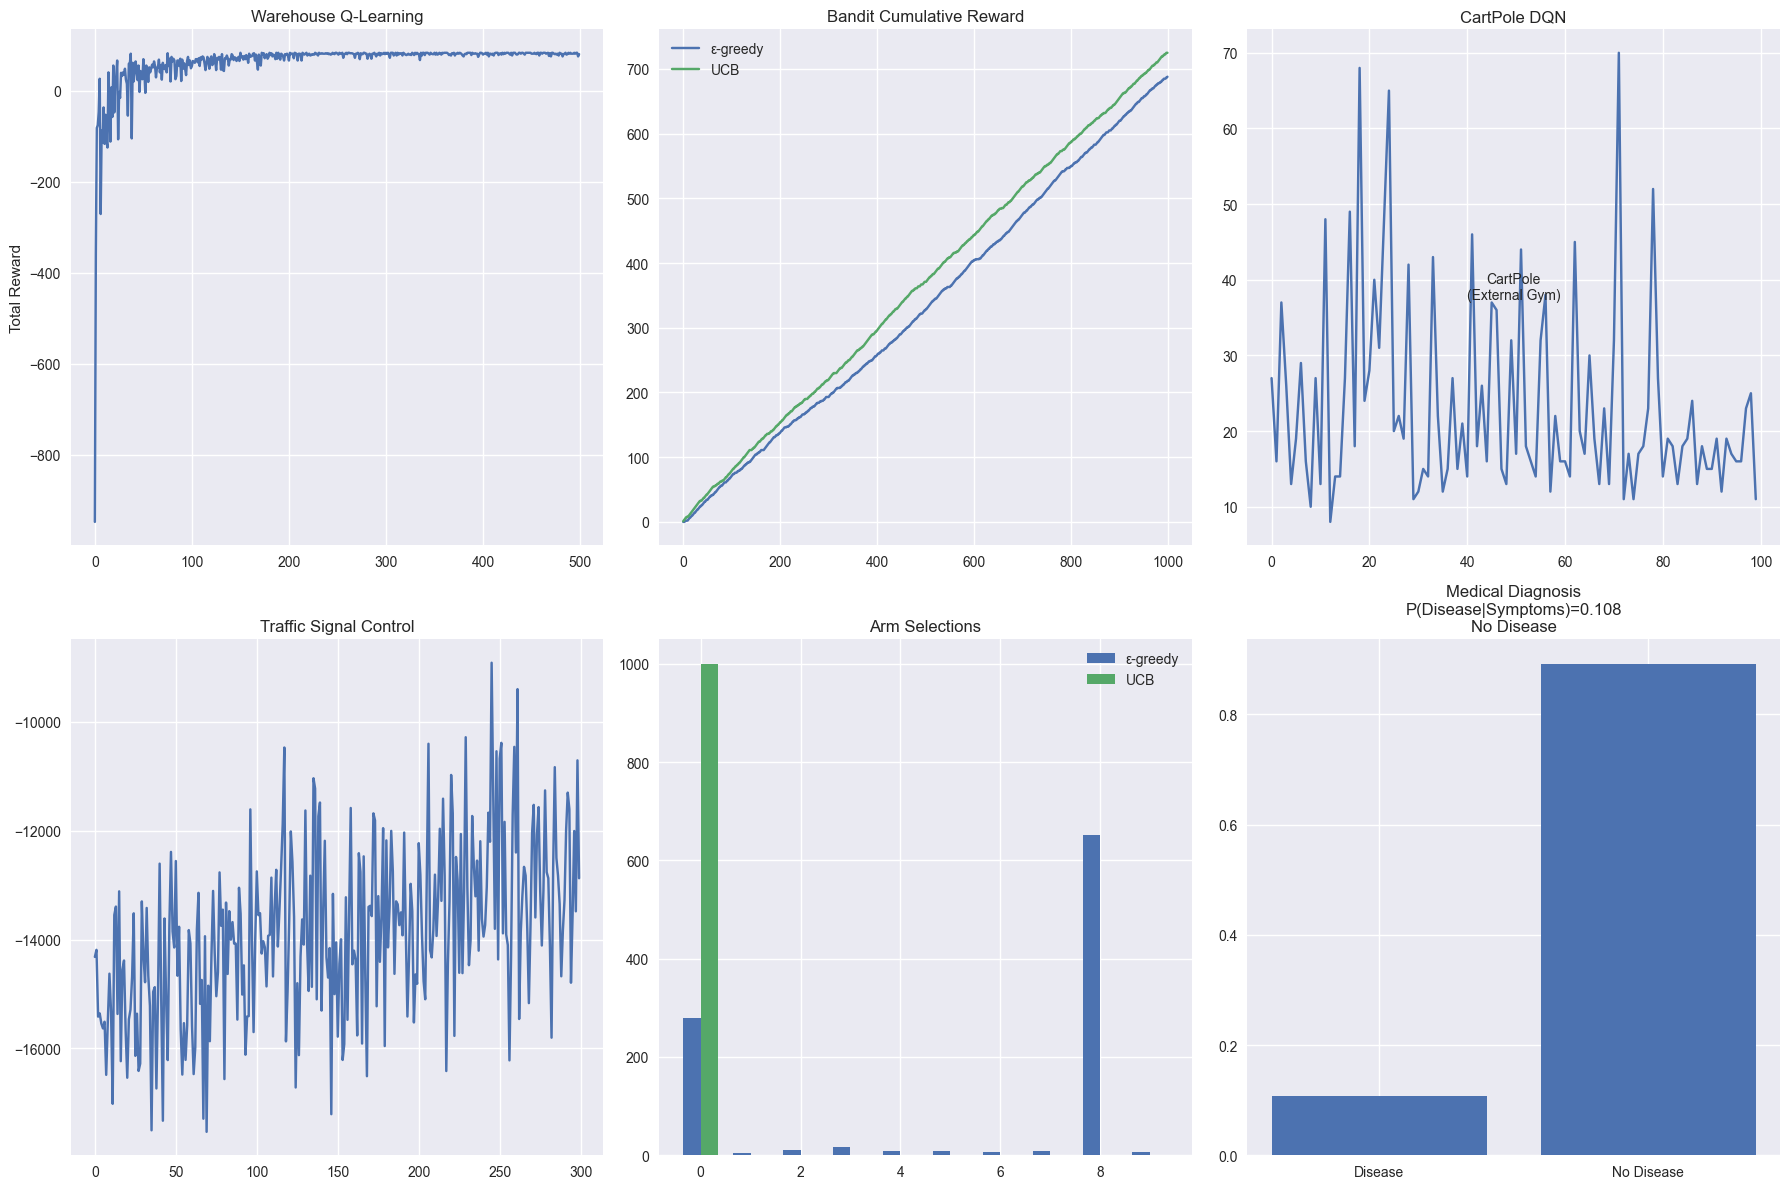


Medical Diagnosis Result: No Disease (Posterior: 0.108)


In [6]:
def run_all_exercises():
    plt.style.use('seaborn-v0_8')
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()
    
    print("=== Exercise 1: Warehouse Navigation ===")
    env1 = WarehouseEnv()
    agent1 = QLearningWarehouse(env1)
    rewards1 = agent1.train(episodes=500)
    axes[0].plot(rewards1)
    axes[0].set_title('Warehouse Q-Learning')
    axes[0].set_ylabel('Total Reward')
    
    print("\n=== Exercise 2: K-Armed Bandit ===")
    e_rewards, u_rewards, e_sel, u_sel, true_probs = simulate_bandits(1000)
    axes[1].plot(np.cumsum(e_rewards), label='ε-greedy')
    axes[1].plot(np.cumsum(u_rewards), label='UCB')
    axes[1].legend()
    axes[1].set_title('Bandit Cumulative Reward')
    
    x = np.arange(10)
    width = 0.35
    axes[4].bar(x - width/2, e_sel, width, label='ε-greedy')
    axes[4].bar(x + width/2, u_sel, width, label='UCB')
    axes[4].set_title('Arm Selections')
    axes[4].legend()
    
    print("\n=== Exercise 3: CartPole ===")
    dqn = DQNCartPole()
    rewards3 = dqn.train(100)
    axes[2].plot(rewards3)
    axes[2].set_title('CartPole DQN')
    axes[2].text(0.5, 0.5, 'CartPole\n(External Gym)', ha='center', va='center', transform=axes[2].transAxes)
    
    print("\n=== Exercise 4: Traffic Control ===")
    env4 = TrafficEnv()
    agent4 = TrafficQLearning(env4)
    rewards4 = agent4.train(300)
    axes[3].plot(rewards4)
    axes[3].set_title('Traffic Signal Control')
    
    print("\n=== Exercise 5: Medical Diagnosis ===")
    diagnosis = MedicalDiagnosis()
    diagnosis.add_symptom('fever', 0.9, 0.3)
    diagnosis.add_symptom('cough', 0.8, 0.2)
    diagnosis.add_symptom('fatigue', 0.7, 0.4)
    
    posterior, result = diagnosis.bayes_theorem(['fever', 'cough'])
    axes[5].bar(['Disease', 'No Disease'], [posterior, 1-posterior])
    axes[5].set_title(f'Medical Diagnosis\nP(Disease|Symptoms)={posterior:.3f}\n{result}')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nMedical Diagnosis Result: {result} (Posterior: {posterior:.3f})")

if __name__ == "__main__":
    run_all_exercises()
